# Phase 2: Add Risk Factors

Phase 2 of the upgrade adds the four continuous risk factors that
drive cardiovascular outcomes in the model:

| Risk | Units | Distribution |
|------|-------|--------------|
| High systolic blood pressure | mmHg | Ensemble |
| High LDL cholesterol | mmol/L | Ensemble |
| High BMI (adults) | kg/m^2 | Ensemble |
| High fasting plasma glucose | mmol/L | Ensemble |

The model spec used here is
`src/vivarium_nih_us_cvd/model_specifications/nih_us_cvd_phase2.yaml`.
It is exactly Phase 1 plus four `Risk(...)` declarations from
`vivarium_public_health` for the risks above. The project's custom
`AdjustedRisk` / `TruncatedRisk` / `CorrelatedRisk` subclasses are
NOT used in this phase: they depend on multiplier columns created
by the `Treatment` component which is introduced in Phase 4.

What this notebook checks:

1. The four `Risk` components register cleanly with the new
   GBD 2023 artifact (which has 250 draws and the `parameter`
   index level on the exposure tables).
2. The propensity columns are created at initialization and the
   exposure pipelines return reasonable distributions for adults.
3. Stepping the simulation does not crash and does not change
   propensities (they should be fixed at birth/initialization).


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vivarium import InteractiveContext

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

MODEL_SPEC = '../src/vivarium_nih_us_cvd/model_specifications/nih_us_cvd_phase2.yaml'

RISK_NAMES = [
    'high_systolic_blood_pressure',
    'high_ldl_cholesterol',
    'high_body_mass_index_in_adults',
    'high_fasting_plasma_glucose',
]
RISK_UNITS = {
    'high_systolic_blood_pressure': 'mmHg',
    'high_ldl_cholesterol': 'mmol/L',
    'high_body_mass_index_in_adults': 'kg/m^2',
    'high_fasting_plasma_glucose': 'mmol/L',
}


## 1. Set up the simulation

If `InteractiveContext(...)` returns without raising, the four risk
factor components have:

- loaded their exposure / standard deviation / distribution weight
  tables from the artifact,
- built `EnsembleDistribution` objects, and
- registered the propensity initializers and exposure pipelines.


In [2]:
sim = InteractiveContext(MODEL_SPEC)
print('setup OK')
print('current time:', sim.current_time)


setup OK
current time: 2024-01-01 00:00:00


## 2. Inspect registered risk pipelines

vph 5 registers a `<risk>.exposure` value pipeline (and a
`<risk>.exposure.propensity` propensity column) for every continuous
risk. We list them here as proof that the components wired
themselves up.


In [3]:
risk_attrs = [
    a for a in sim.get_attribute_names()
    if any(r in a for r in RISK_NAMES)
]
for a in sorted(risk_attrs):
    print(' ', a)


  ensemble_propensity.risk_factor.high_body_mass_index_in_adults
  ensemble_propensity.risk_factor.high_fasting_plasma_glucose
  ensemble_propensity.risk_factor.high_ldl_cholesterol
  ensemble_propensity.risk_factor.high_systolic_blood_pressure
  high_body_mass_index_in_adults.exposure
  high_body_mass_index_in_adults.exposure_distribution.ppf
  high_body_mass_index_in_adults.propensity
  high_fasting_plasma_glucose.exposure
  high_fasting_plasma_glucose.exposure_distribution.ppf
  high_fasting_plasma_glucose.propensity
  high_ldl_cholesterol.exposure
  high_ldl_cholesterol.exposure_distribution.ppf
  high_ldl_cholesterol.propensity
  high_systolic_blood_pressure.exposure
  high_systolic_blood_pressure.exposure_distribution.ppf
  high_systolic_blood_pressure.propensity


## 3. Pull a population view including all risk exposures and propensities


In [4]:
ATTRS = ['age', 'sex', 'is_alive']
ATTRS += [f'{r}.exposure' for r in RISK_NAMES]
ATTRS += [f'{r}.propensity' for r in RISK_NAMES]
ATTRS += ['ischemic_stroke', 'ischemic_heart_disease_and_heart_failure']

pop = sim.get_population(ATTRS)
print('shape:', pop.shape)
print()
print(pop.head())


shape: (1000, 13)

         age     sex  is_alive  high_systolic_blood_pressure.exposure  high_ldl_cholesterol.exposure  high_body_mass_index_in_adults.exposure  high_fasting_plasma_glucose.exposure  \
0  52.886352  Female      True                             122.300801                       3.233614                                29.763196                              7.406651   
1  81.557394  Female      True                             141.535996                       3.413722                                17.206446                              5.475160   
2  71.985765    Male      True                             142.555967                       1.670521                                33.082305                              8.016502   
3  47.572942    Male      True                             130.688714                       2.165045                                27.101684                              6.636471   
4  54.727528    Male      True                             141.457

## 4. Risk exposure summary statistics

Adults (age >= 25) are the cohort for which the artifact has
non-trivial exposure data. Children carry zeros / placeholder values.
Exclude them when summarising.


In [5]:
adults = pop[pop['age'] >= 25].copy()
print(f'{len(adults)} adults out of {len(pop)} simulants')
print()

summary = adults[[f'{r}.exposure' for r in RISK_NAMES]].describe().round(2).T
summary.index = [s.replace('.exposure', '') for s in summary.index]
summary['units'] = [RISK_UNITS[r] for r in summary.index]
print(summary[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'units']])


726 adults out of 1000 simulants

                                count    mean    std    min     25%     50%     75%     max   units
high_systolic_blood_pressure    726.0  124.27  18.23  42.88  112.58  122.30  134.44  203.75    mmHg
high_ldl_cholesterol            726.0    3.00   0.96  -1.05    2.34    2.90    3.62    7.48  mmol/L
high_body_mass_index_in_adults  726.0   30.15   7.42  -6.90   25.19   29.56   34.42   68.03  kg/m^2
high_fasting_plasma_glucose     726.0    6.26   2.31  -2.86    4.83    5.74    7.14   24.81  mmol/L


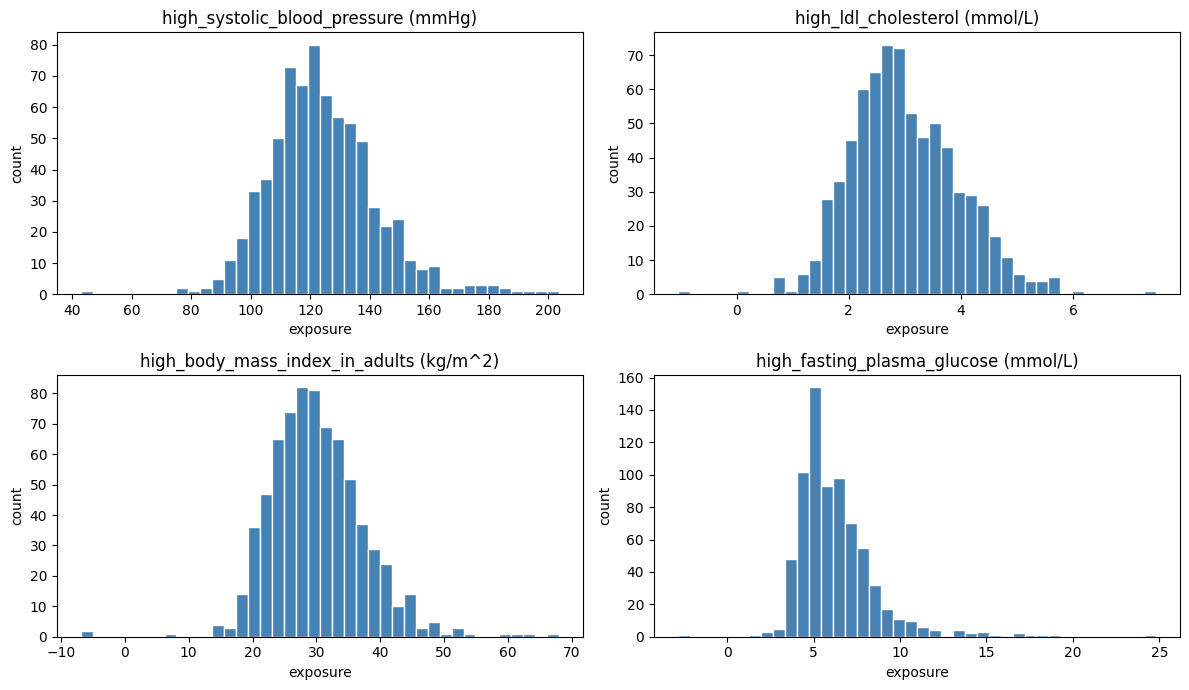

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, risk in zip(axes.ravel(), RISK_NAMES):
    vals = adults[f'{risk}.exposure']
    ax.hist(vals, bins=40, color='steelblue', edgecolor='white')
    ax.set_title(f'{risk} ({RISK_UNITS[risk]})')
    ax.set_xlabel('exposure')
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()


## 5. Propensity sanity check

Without `RiskCorrelation` (added in a later phase), each risk's
propensity is sampled independently from a uniform(0, 1).


In [7]:
prop_cols = [f'{r}.propensity' for r in RISK_NAMES]
prop_summary = pop[prop_cols].describe().round(3).T
prop_summary.index = [s.replace('.propensity', '') for s in prop_summary.index]
print(prop_summary[['count', 'mean', 'std', 'min', '50%', 'max']])
print()

# Pairwise correlation should be ~0 (independent uniforms).
corr = pop[prop_cols].corr().round(3)
corr.index = corr.columns = [c.replace('.propensity', '') for c in corr.columns]
print('propensity correlation matrix:')
print(corr)


                                 count   mean    std    min    50%    max
high_systolic_blood_pressure    1000.0  0.492  0.290  0.001  0.497  0.999
high_ldl_cholesterol            1000.0  0.503  0.291  0.001  0.503  0.998
high_body_mass_index_in_adults  1000.0  0.507  0.292  0.000  0.515  1.000
high_fasting_plasma_glucose     1000.0  0.508  0.297  0.001  0.513  1.000

propensity correlation matrix:
                                high_systolic_blood_pressure  high_ldl_cholesterol  high_body_mass_index_in_adults  high_fasting_plasma_glucose
high_systolic_blood_pressure                           1.000                 0.033                          -0.045                       -0.009
high_ldl_cholesterol                                   0.033                 1.000                          -0.008                       -0.041
high_body_mass_index_in_adults                        -0.045                -0.008                           1.000                       -0.020
high_fasting_plasma_gl

## 6. Sex- and age-stratified mean exposure

These should look roughly like the artifact's marginal exposure
means: mean SBP rising into older ages, BMI peaking around middle
age, etc.


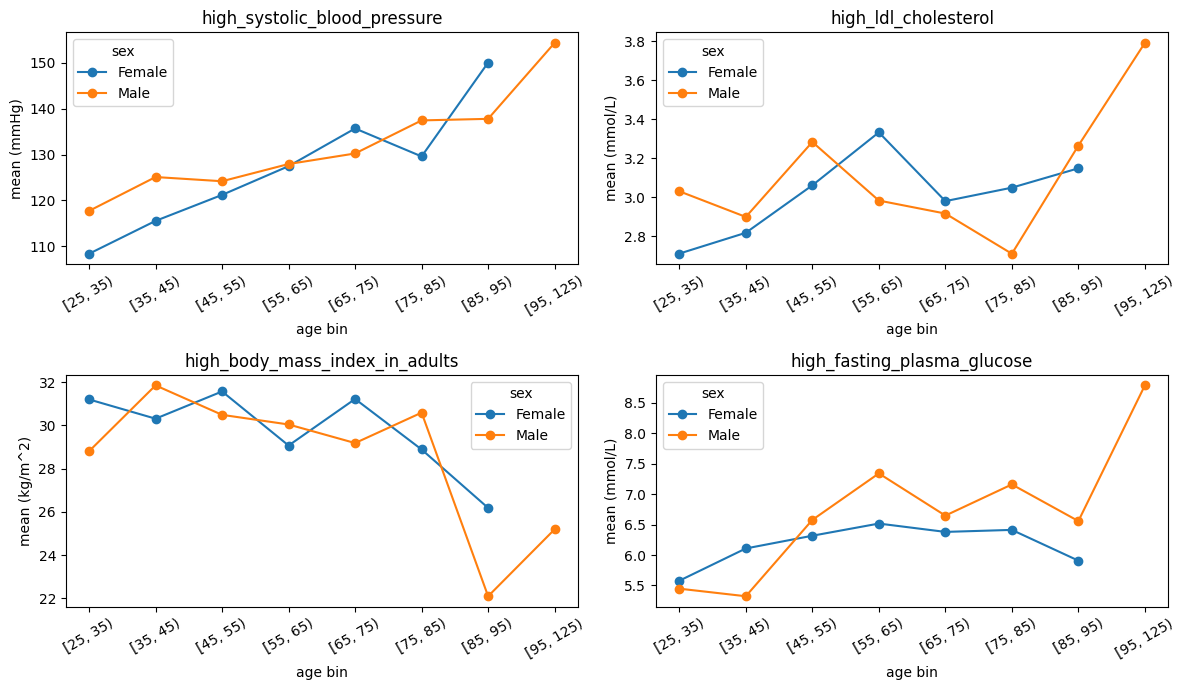

In [8]:
adults['age_bin'] = pd.cut(
    adults['age'],
    bins=[25, 35, 45, 55, 65, 75, 85, 95, 125],
    right=False,
)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, risk in zip(axes.ravel(), RISK_NAMES):
    means = (
        adults
        .groupby(['age_bin', 'sex'], observed=True)[f'{risk}.exposure']
        .mean()
        .unstack('sex')
    )
    means.plot(ax=ax, marker='o')
    ax.set_title(risk)
    ax.set_ylabel(f'mean ({RISK_UNITS[risk]})')
    ax.set_xlabel('age bin')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


## 7. Step the simulation forward

Run for one simulated year and confirm:

- the disease state machines still fire (Phase 1 invariant),
- propensities stay constant (they're set once at initialization),
- exposures may shift slightly due to age changes / table
  interpolation across step times.


In [9]:
prop_before = pop[prop_cols].copy()
exposures_before = pop[[f'{r}.exposure' for r in RISK_NAMES]].copy()

for _ in range(13):  # ~1 year
    sim.step()
print('current time:', sim.current_time)

pop2 = sim.get_population(ATTRS)
print('alive after 1y:', int(pop2['is_alive'].sum()), '/', len(pop2))


current time: 2024-12-30 00:00:00


alive after 1y: 993 / 1000


In [10]:
common = pop.index.intersection(pop2.index)
prop_changed = (pop2.loc[common, prop_cols] != prop_before.loc[common]).any().any()
print('any propensity changed?', prop_changed)
print()

# Exposure means before / after
mean_before = pop.loc[pop['age'] >= 25, [f'{r}.exposure' for r in RISK_NAMES]].mean().round(2)
mean_after  = pop2.loc[pop2['age'] >= 25, [f'{r}.exposure' for r in RISK_NAMES]].mean().round(2)
delta = (mean_after - mean_before).round(3)
print(pd.DataFrame({'before': mean_before, 'after_1y': mean_after, 'delta': delta}))


any propensity changed? False

                                         before  after_1y  delta
high_systolic_blood_pressure.exposure    124.27    124.47   0.20
high_ldl_cholesterol.exposure              3.00      2.99  -0.01
high_body_mass_index_in_adults.exposure   30.15     30.12  -0.03
high_fasting_plasma_glucose.exposure       6.26      6.26   0.00


## 8. Verdict

If you reached this cell with no exceptions and:

- The four risk factor components registered without errors,
- Adult exposure summaries look physiologically reasonable
  (e.g. mean SBP in the 120s mmHg, mean LDL-C in the 2s-3s mmol/L,
  mean BMI in the 25-30 kg/m^2 range, mean FPG in the 5s-6s mmol/L),
- The propensity values are uniform-ish on (0, 1) and uncorrelated
  pairwise (no `RiskCorrelation` yet),
- One year of stepping completes without errors and propensities
  stay frozen,

then **Phase 2 is complete**. The next phase will hook up
`MediatedRiskEffect` so that the relative-risk artifact data is
applied to disease transition rates.
